# 01 - Thống kê mô tả, phân phối và tương quan

Notebook này dùng `wage_eda.csv` để trả lời phần EDA: thống kê mô tả, missing value, phân phối và tương quan các biến quan trọng.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")


def find_project_root() -> Path:
    current = Path.cwd().resolve()
    candidates = [current, *current.parents]
    for base in candidates:
        if (base / "data" / "wage_model.csv").exists():
            return base
        nested = base / "Machine Learning"
        if (nested / "data" / "wage_model.csv").exists():
            return nested
    raise FileNotFoundError("Không tìm thấy data/wage_model.csv. Hãy mở notebook trong folder Machine Learning.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
RESULT_DIR = OUTPUT_DIR / "model_results"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

eda_df = pd.read_csv(DATA_DIR / "wage_eda.csv")
model_df = pd.read_csv(DATA_DIR / "wage_model.csv")

print("Project root found.")
print("EDA data:", eda_df.shape)
print("Model data:", model_df.shape)


Project root found.
EDA data: (3010, 30)
Model data: (3010, 38)


## 1.1 Thống kê mô tả

Tập trung vào `lwage`, `wage`, học vấn, kinh nghiệm, năng lực, biến gia đình và biến vùng.


In [2]:
main_cols = [
    "lwage", "wage", "educ", "exper", "expersq", "IQ", "KWW",
    "black", "married", "south", "smsa", "fatheduc", "motheduc",
]
main_cols = [col for col in main_cols if col in eda_df.columns]

display(eda_df[main_cols].describe().T.round(3))
display(eda_df[main_cols].isna().sum().rename("missing_count").to_frame())


,count,mean,std,min,25%,50%,75%,max
lwage,3010.0,6.262,0.444,4.605,5.977,6.287,6.564,7.785
wage,3010.0,577.282,262.958,100.000,394.250,537.500,708.750,2404.000
educ,3010.0,13.263,2.677,1.000,12.000,13.000,16.000,18.000
exper,3010.0,8.856,4.142,0.000,6.000,8.000,11.000,23.000
expersq,3010.0,95.579,84.618,0.000,36.000,64.000,121.000,529.000
IQ,2061.0,102.450,15.424,50.000,93.000,103.000,113.000,149.000
KWW,2963.0,33.541,8.612,4.000,28.000,34.000,40.000,56.000
black,3010.0,0.234,0.423,0.000,0.000,0.000,0.000,1.000
married,3003.0,2.271,2.067,1.000,1.000,1.000,4.000,6.000
south,3010.0,0.404,0.491,0.000,0.000,0.000,1.000,1.000


,missing_count
lwage,0
wage,0
educ,0
exper,0
expersq,0
IQ,949
KWW,47
black,0
married,7
south,0


## 1.2 Phân phối các biến chính


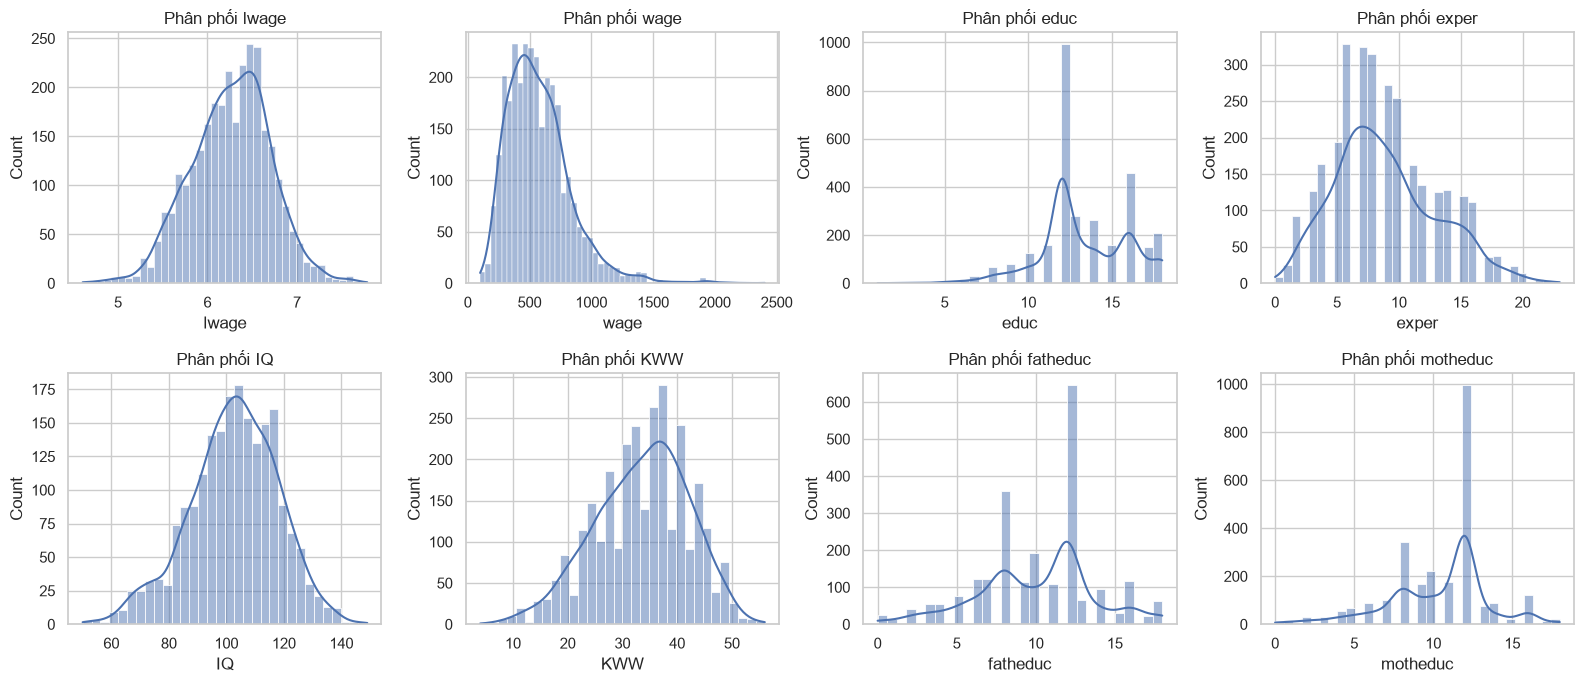

In [3]:
plot_cols = ["lwage", "wage", "educ", "exper", "IQ", "KWW", "fatheduc", "motheduc"]
plot_cols = [col for col in plot_cols if col in eda_df.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.ravel()

for ax, col in zip(axes, plot_cols):
    sns.histplot(eda_df[col], kde=True, ax=ax)
    ax.set_title(f"Phân phối {col}")
    ax.set_xlabel(col)

for ax in axes[len(plot_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIG_DIR / "01_histograms.png", dpi=200)
plt.show()


## 1.3 Tương quan giữa các biến số


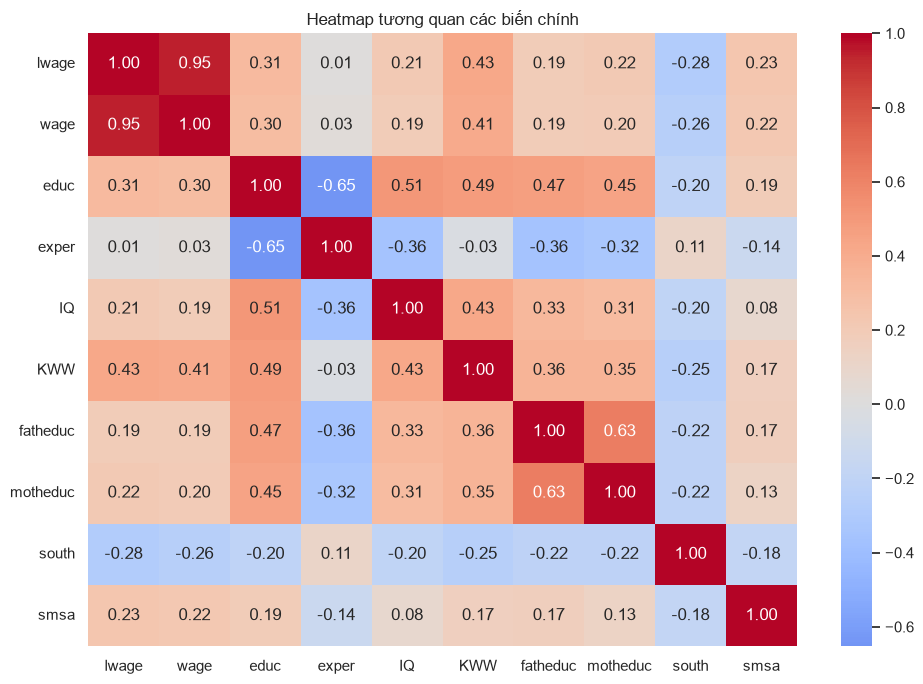

,corr_with_lwage
lwage,1.000
wage,0.947
KWW,0.428
educ,0.314
smsa,0.235
motheduc,0.216
IQ,0.213
fatheduc,0.191
exper,0.012
south,-0.284


In [4]:
corr_cols = ["lwage", "wage", "educ", "exper", "IQ", "KWW", "fatheduc", "motheduc", "south", "smsa"]
corr_cols = [col for col in corr_cols if col in eda_df.columns]
corr = eda_df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Heatmap tương quan các biến chính")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_correlation_heatmap.png", dpi=200)
plt.show()

display(corr["lwage"].sort_values(ascending=False).round(3).rename("corr_with_lwage").to_frame())


## Nhận xét ngắn

- `educ`, `IQ`, `KWW` và nền tảng gia đình thường có tương quan dương với `lwage`.
- `wage` chỉ dùng cho EDA, không dùng làm biến đầu vào mô hình vì có quan hệ trực tiếp với `lwage`.
- Tương quan chỉ mô tả quan hệ hai biến, chưa phải kết luận nhân quả.
